Titanic_EDA_Assignment.ipynb


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load built-in dataset
df = sns.load_dataset('titanic')

# Show first 5 rows
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Check data dimensions
print("Dataset Shape:", df.shape)

# Check data types
print("\n--- Column Info ---")
df.info()

# Statistical breakdown (mean, median, std)
print("\n--- Summary Statistics ---")
print(df.describe())

# Check for null values
print("\n--- Missing Values Summary ---")
print(df.isnull().sum())


Dataset Shape: (891, 15)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Summary Statistics ---
     

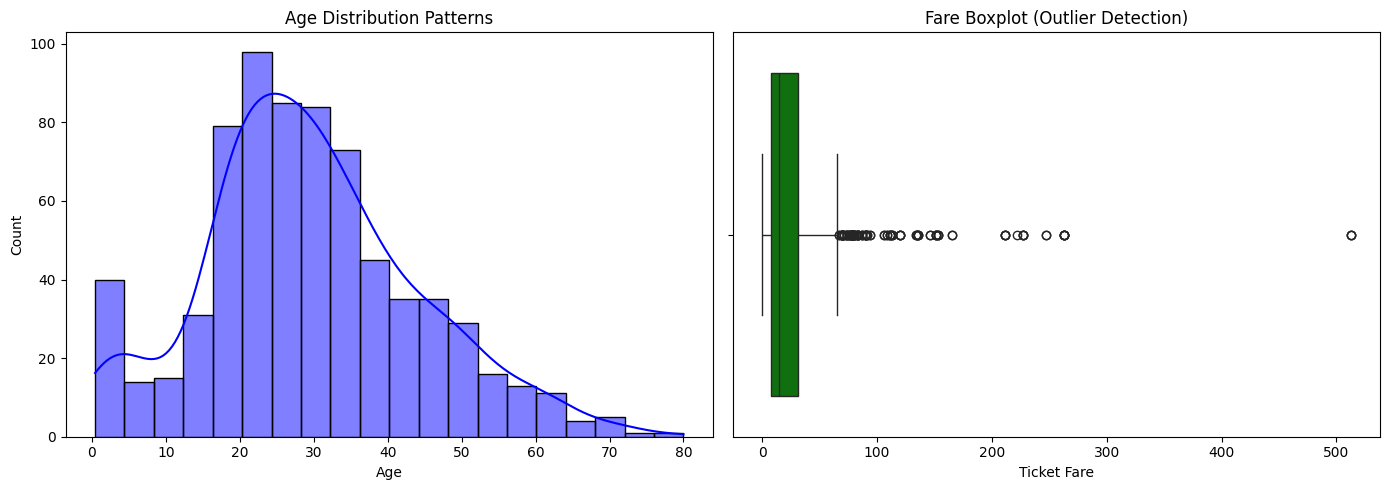

In [5]:
# Create a layout window for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age Histogram
sns.histplot(df['age'].dropna(), kde=True, color='blue', ax=axes[0])
axes[0].set_title('Age Distribution Patterns')
axes[0].set_xlabel('Age')

# Plot 2: Fare Boxplot to find outliers
sns.boxplot(x=df['fare'], color='green', ax=axes[1])
axes[1].set_title('Fare Boxplot (Outlier Detection)')
axes[1].set_xlabel('Ticket Fare')

plt.tight_layout()
plt.show()



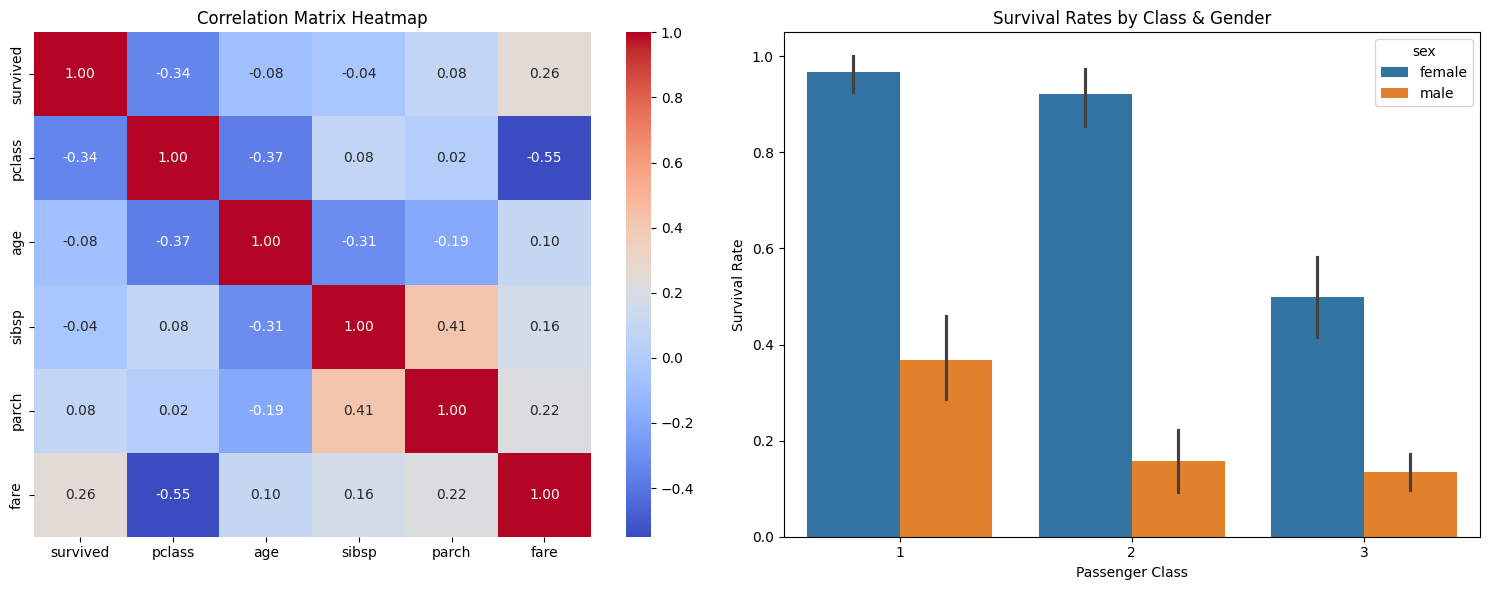

In [6]:
# Set up a layout window for relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Heatmap of numerical relationships
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Correlation Matrix Heatmap')

# Plot 2: Survival rates by class and gender
sns.barplot(x='pclass', y='survived', hue='sex', data=df, ax=axes[1])
axes[1].set_title('Survival Rates by Class & Gender')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()
